# Delhi NCR Air Quality Analysis & Prediction
# This project focuses on analyzing air pollution levels in Delhi NCR using data preprocessing, visualization, and machine learning techniques.

# Installing Dataset
# Installing the dataset using KaggleHub to ensure reproducibility and avoid manual downloads.

In [1]:
# Installing KaggleHub
!pip install kagglehub

# Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


# Loading Dataset
# Fetching dataset directly from KaggleHub.

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("vishardmehta/delhi-pollution-aqi-dataset")

# Finding CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset loaded successfully ✔️")
df.head()

Dataset loaded successfully ✔️


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


# Basic Dataset Overview

In [4]:
print('=== DATASET INFO ===')
df.info()

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== STATISTICAL SUMMARY ===')
df.describe(include='all')

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-nu

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
count,201664,201664,201664.000000,201664.000000,201664.000000,201664.000000,201664,201664.000000,201664,201664,...,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664
unique,8768,2192,NaN,NaN,NaN,NaN,7,NaN,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,2020-01-01 06:00:00,2020-01-01,NaN,NaN,NaN,NaN,Wednesday,NaN,monsoon,Delhi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Severe
freq,23,92,NaN,NaN,NaN,NaN,28888,NaN,67344,122752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60102
mean,NaN,NaN,2022.499544,6.521898,15.732664,14.750000,NaN,0.285584,NaN,NaN,...,69.761495,16.028998,3.033964,27.185762,26.895227,61.041564,10.528524,5.007801,265.830148,NaN
std,NaN,NaN,1.708185,3.448995,8.801392,6.378691,NaN,0.451693,NaN,NaN,...,75.972086,17.201027,3.284094,13.569802,8.984843,24.737106,6.045043,3.685609,171.508950,NaN
min,NaN,NaN,2020.000000,1.000000,1.000000,6.000000,NaN,0.000000,NaN,NaN,...,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000,NaN
25%,NaN,NaN,2021.000000,4.000000,8.000000,10.500000,NaN,0.000000,NaN,NaN,...,19.900000,4.500000,0.870000,18.000000,19.900000,39.000000,5.900000,1.900000,103.000000,NaN
50%,NaN,NaN,2022.500000,7.000000,16.000000,15.000000,NaN,0.000000,NaN,NaN,...,38.300000,8.700000,1.690000,23.300000,27.600000,58.000000,9.200000,4.400000,232.000000,NaN
75%,NaN,NaN,2024.000000,10.000000,23.000000,19.250000,NaN,1.000000,NaN,NaN,...,94.000000,20.900000,4.120000,31.800000,33.500000,83.000000,14.200000,7.100000,464.000000,NaN


# Missing Value Analysis & Visualization

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✅ No missing values found in the dataset!


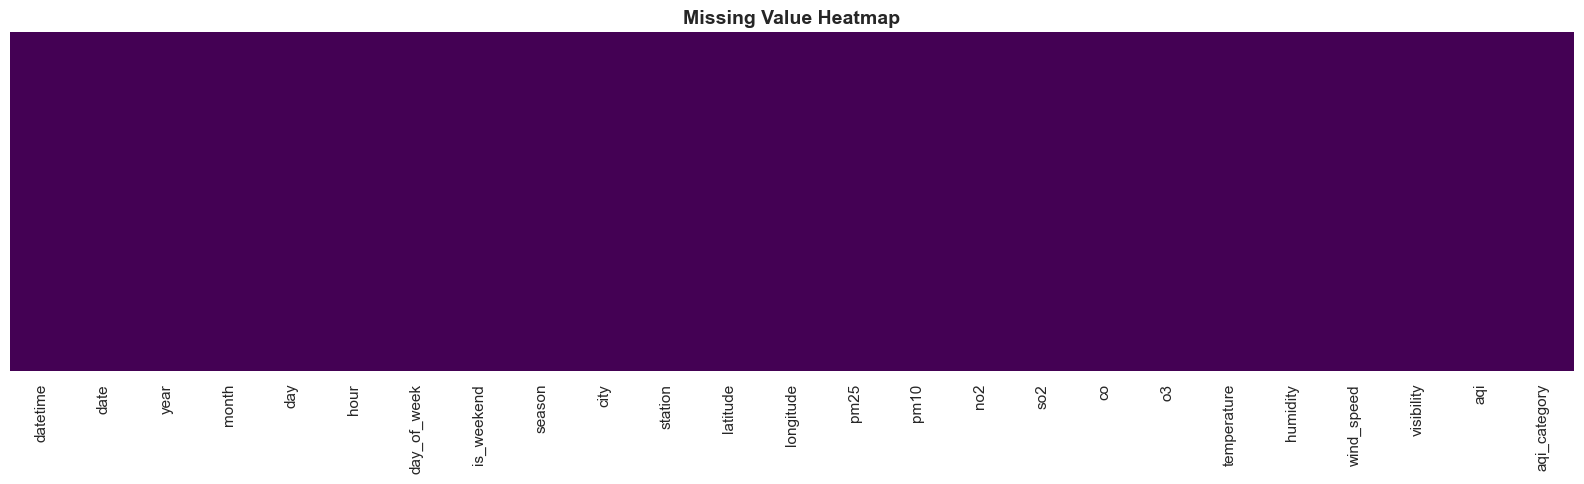

In [5]:
# --- Check missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print('\n✅ No missing values found in the dataset!')

# --- Visualize missing values as heatmap ---
plt.figure(figsize=(16, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Handle Missing Values (Expert Strategy)

In [6]:
# Even though there are no missing values, we demonstrate expert handling:
# - Numerical columns → impute with MEDIAN (robust to outliers)
# - Categorical columns → impute with MODE (most frequent)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical columns:', numerical_cols)
print('\nCategorical columns:', categorical_cols)

# Simulate missing values to demonstrate (5% random)
df_demo = df.copy()
np.random.seed(42)

for col in ['pm25', 'pm10', 'temperature', 'humidity']:
    mask = np.random.choice([True, False], size=len(df_demo), p=[0.05, 0.95])
    df_demo.loc[mask, col] = np.nan

print('\nSimulated missing values in demo copy:')
print(df_demo[['pm25', 'pm10', 'temperature', 'humidity']].isnull().sum())

# Impute numerical → median
for col in ['pm25', 'pm10', 'temperature', 'humidity']:
    median_val = df_demo[col].median()
    df_demo[col].fillna(median_val, inplace=True)
    print(f'  [Numerical] {col}: filled {mask.sum()} NaNs with median = {median_val:.2f}')

print('\n✅ After imputation, missing values:')
print(df_demo[['pm25', 'pm10', 'temperature', 'humidity']].isnull().sum())

# We work with the original clean df going forward
print('\n✅ Working with original clean dataset (no actual missing values).')

Numerical columns: ['year', 'month', 'day', 'hour', 'is_weekend', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

Categorical columns: ['datetime', 'date', 'day_of_week', 'season', 'city', 'station', 'aqi_category']

Simulated missing values in demo copy:
pm25            9943
pm10           10053
temperature     9985
humidity        9964
dtype: int64
  [Numerical] pm25: filled 9964 NaNs with median = 99.50
  [Numerical] pm10: filled 9964 NaNs with median = 189.70
  [Numerical] temperature: filled 9964 NaNs with median = 27.60
  [Numerical] humidity: filled 9964 NaNs with median = 58.00

✅ After imputation, missing values:
pm25           0
pm10           0
temperature    0
humidity       0
dtype: int64

✅ Working with original clean dataset (no actual missing values).


# Target Variable Distribution (PM2.5)

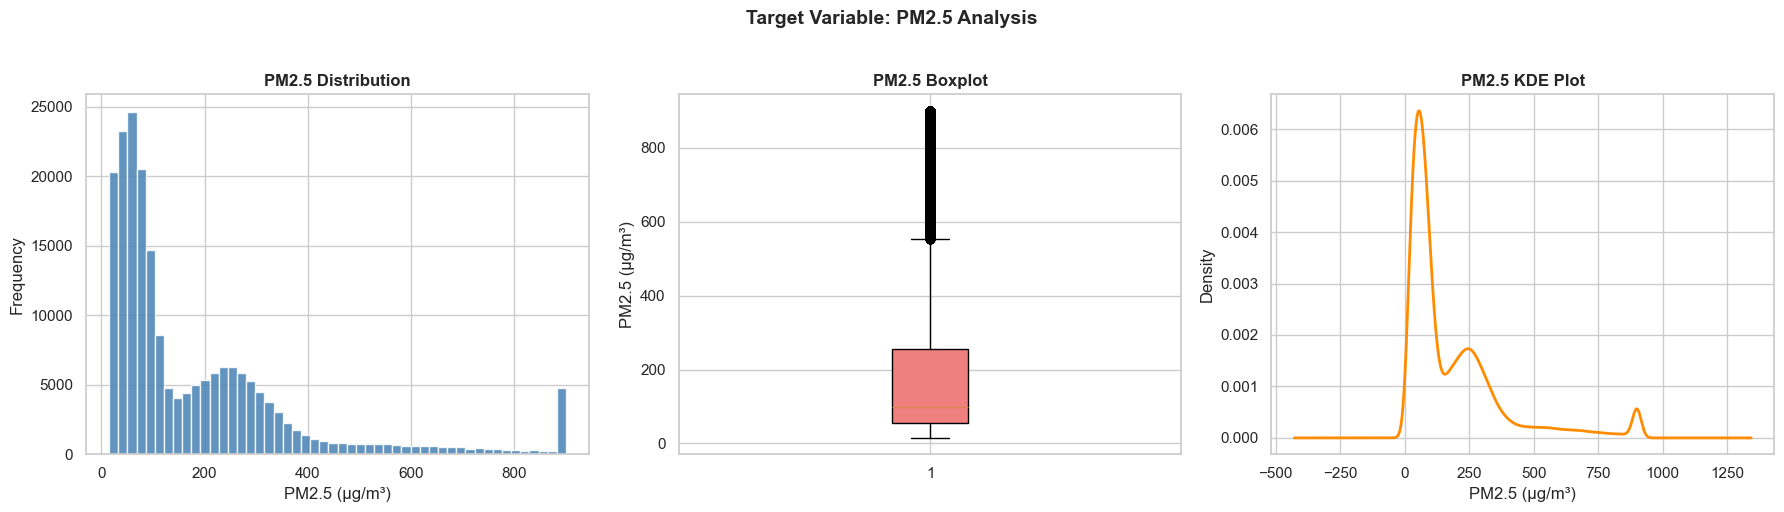

Skewness: 2.001
Kurtosis: 4.050
Mean: 183.42 | Median: 99.50 | Std: 193.14


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['pm25'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('PM2.5 Distribution', fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['pm25'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('PM2.5 Boxplot', fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)')

# KDE
df['pm25'].plot(kind='kde', ax=axes[2], color='darkorange', linewidth=2)
axes[2].set_title('PM2.5 KDE Plot', fontweight='bold')
axes[2].set_xlabel('PM2.5 (µg/m³)')

plt.suptitle('Target Variable: PM2.5 Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness: {df["pm25"].skew():.3f}')
print(f'Kurtosis: {df["pm25"].kurtosis():.3f}')
print(f'Mean: {df["pm25"].mean():.2f} | Median: {df["pm25"].median():.2f} | Std: {df["pm25"].std():.2f}')

# Outlier Detection & Visualization

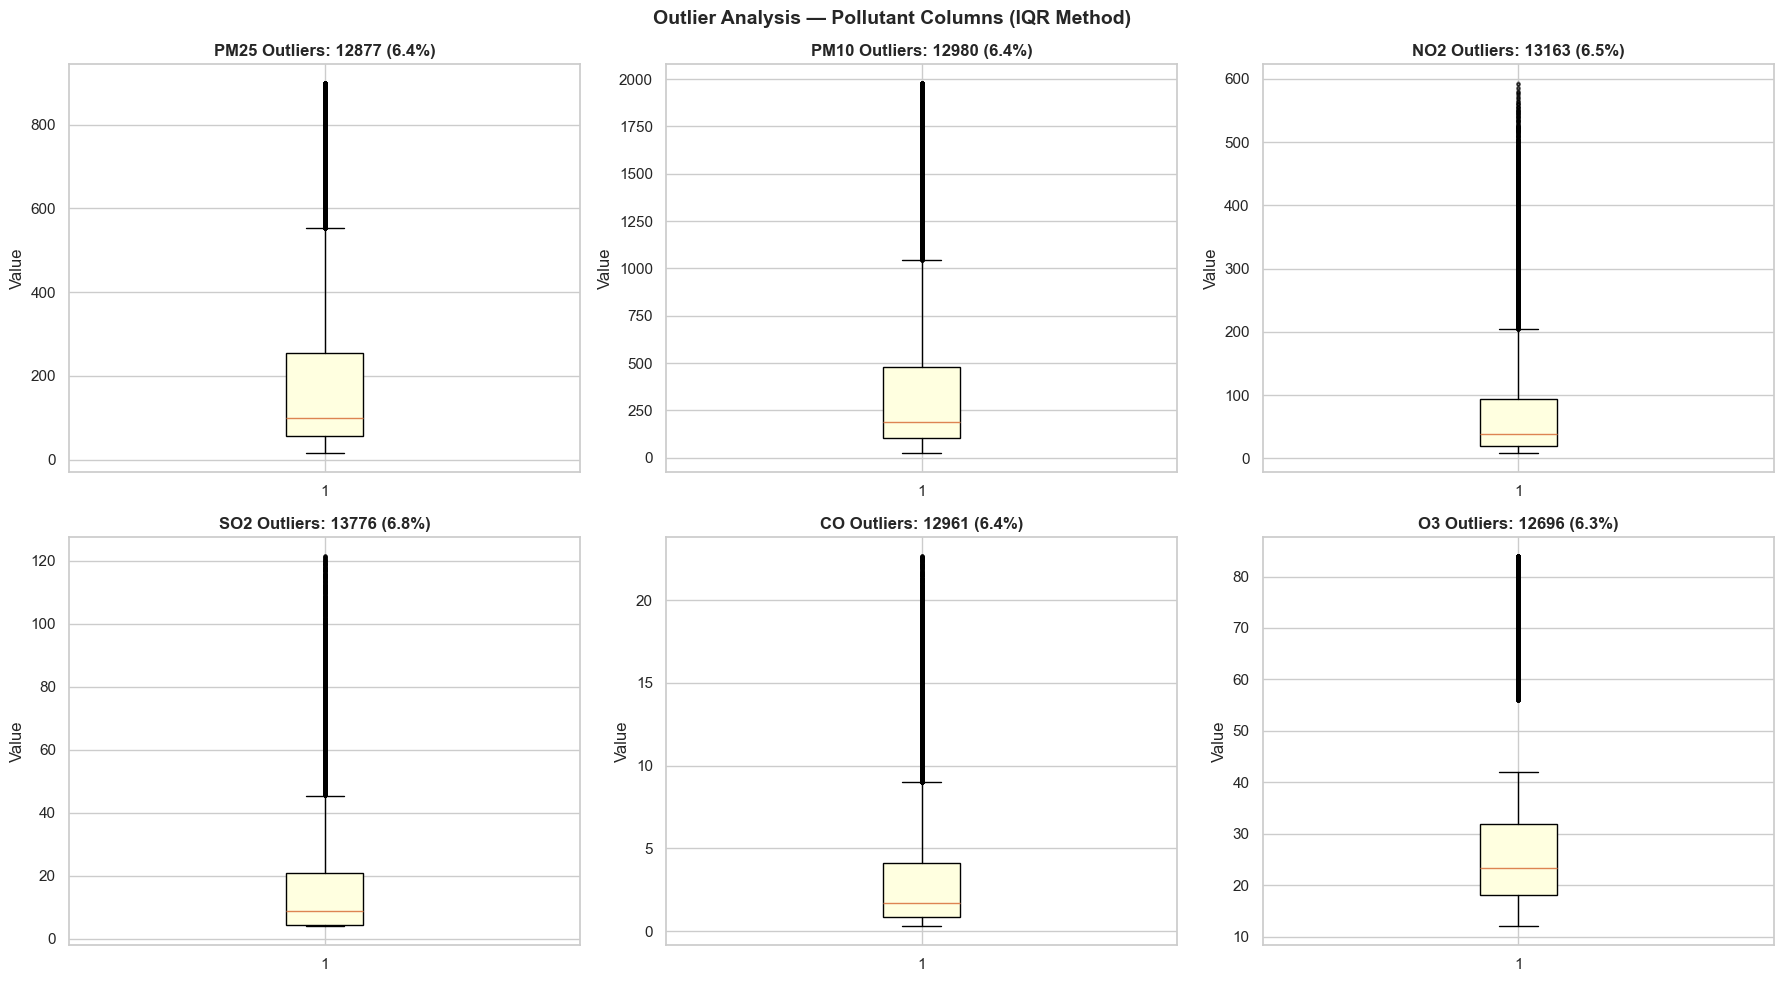

In [8]:
pollutant_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightyellow'),
                    flierprops=dict(marker='o', color='red', markersize=2, alpha=0.4))
    axes[i].set_title(f'{col.upper()} Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
                      fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Analysis — Pollutant Columns (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Expert Outlier Handling (Winsorization)

In [9]:
# Strategy: Winsorize (cap at 1st and 99th percentiles) instead of removing rows.
# Removing rows from pollution data loses real extreme events (smog days).
# Winsorizing retains records but limits distortion.

df_clean = df.copy()

cols_to_winsorize = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
                     'temperature', 'wind_speed', 'visibility']

for col in cols_to_winsorize:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    before_min, before_max = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'{col:15s} | Before: [{before_min:.2f}, {before_max:.2f}] → After: [{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]')

print('\n✅ Winsorization complete! All extreme outliers capped.')

pm25            | Before: [15.00, 900.00] → After: [16.70, 900.00]
pm10            | Before: [24.00, 1979.70] → After: [31.10, 1770.00]
no2             | Before: [8.00, 593.50] → After: [8.00, 358.54]
so2             | Before: [4.00, 121.60] → After: [4.00, 85.10]
co              | Before: [0.30, 22.67] → After: [0.30, 15.57]
o3              | Before: [12.00, 84.00] → After: [12.30, 79.50]
temperature     | Before: [6.00, 44.80] → After: [7.90, 43.80]
wind_speed      | Before: [2.10, 31.50] → After: [2.40, 29.10]
visibility      | Before: [0.20, 15.00] → After: [0.30, 14.60]

✅ Winsorization complete! All extreme outliers capped.


# Distribution of All Numerical Features

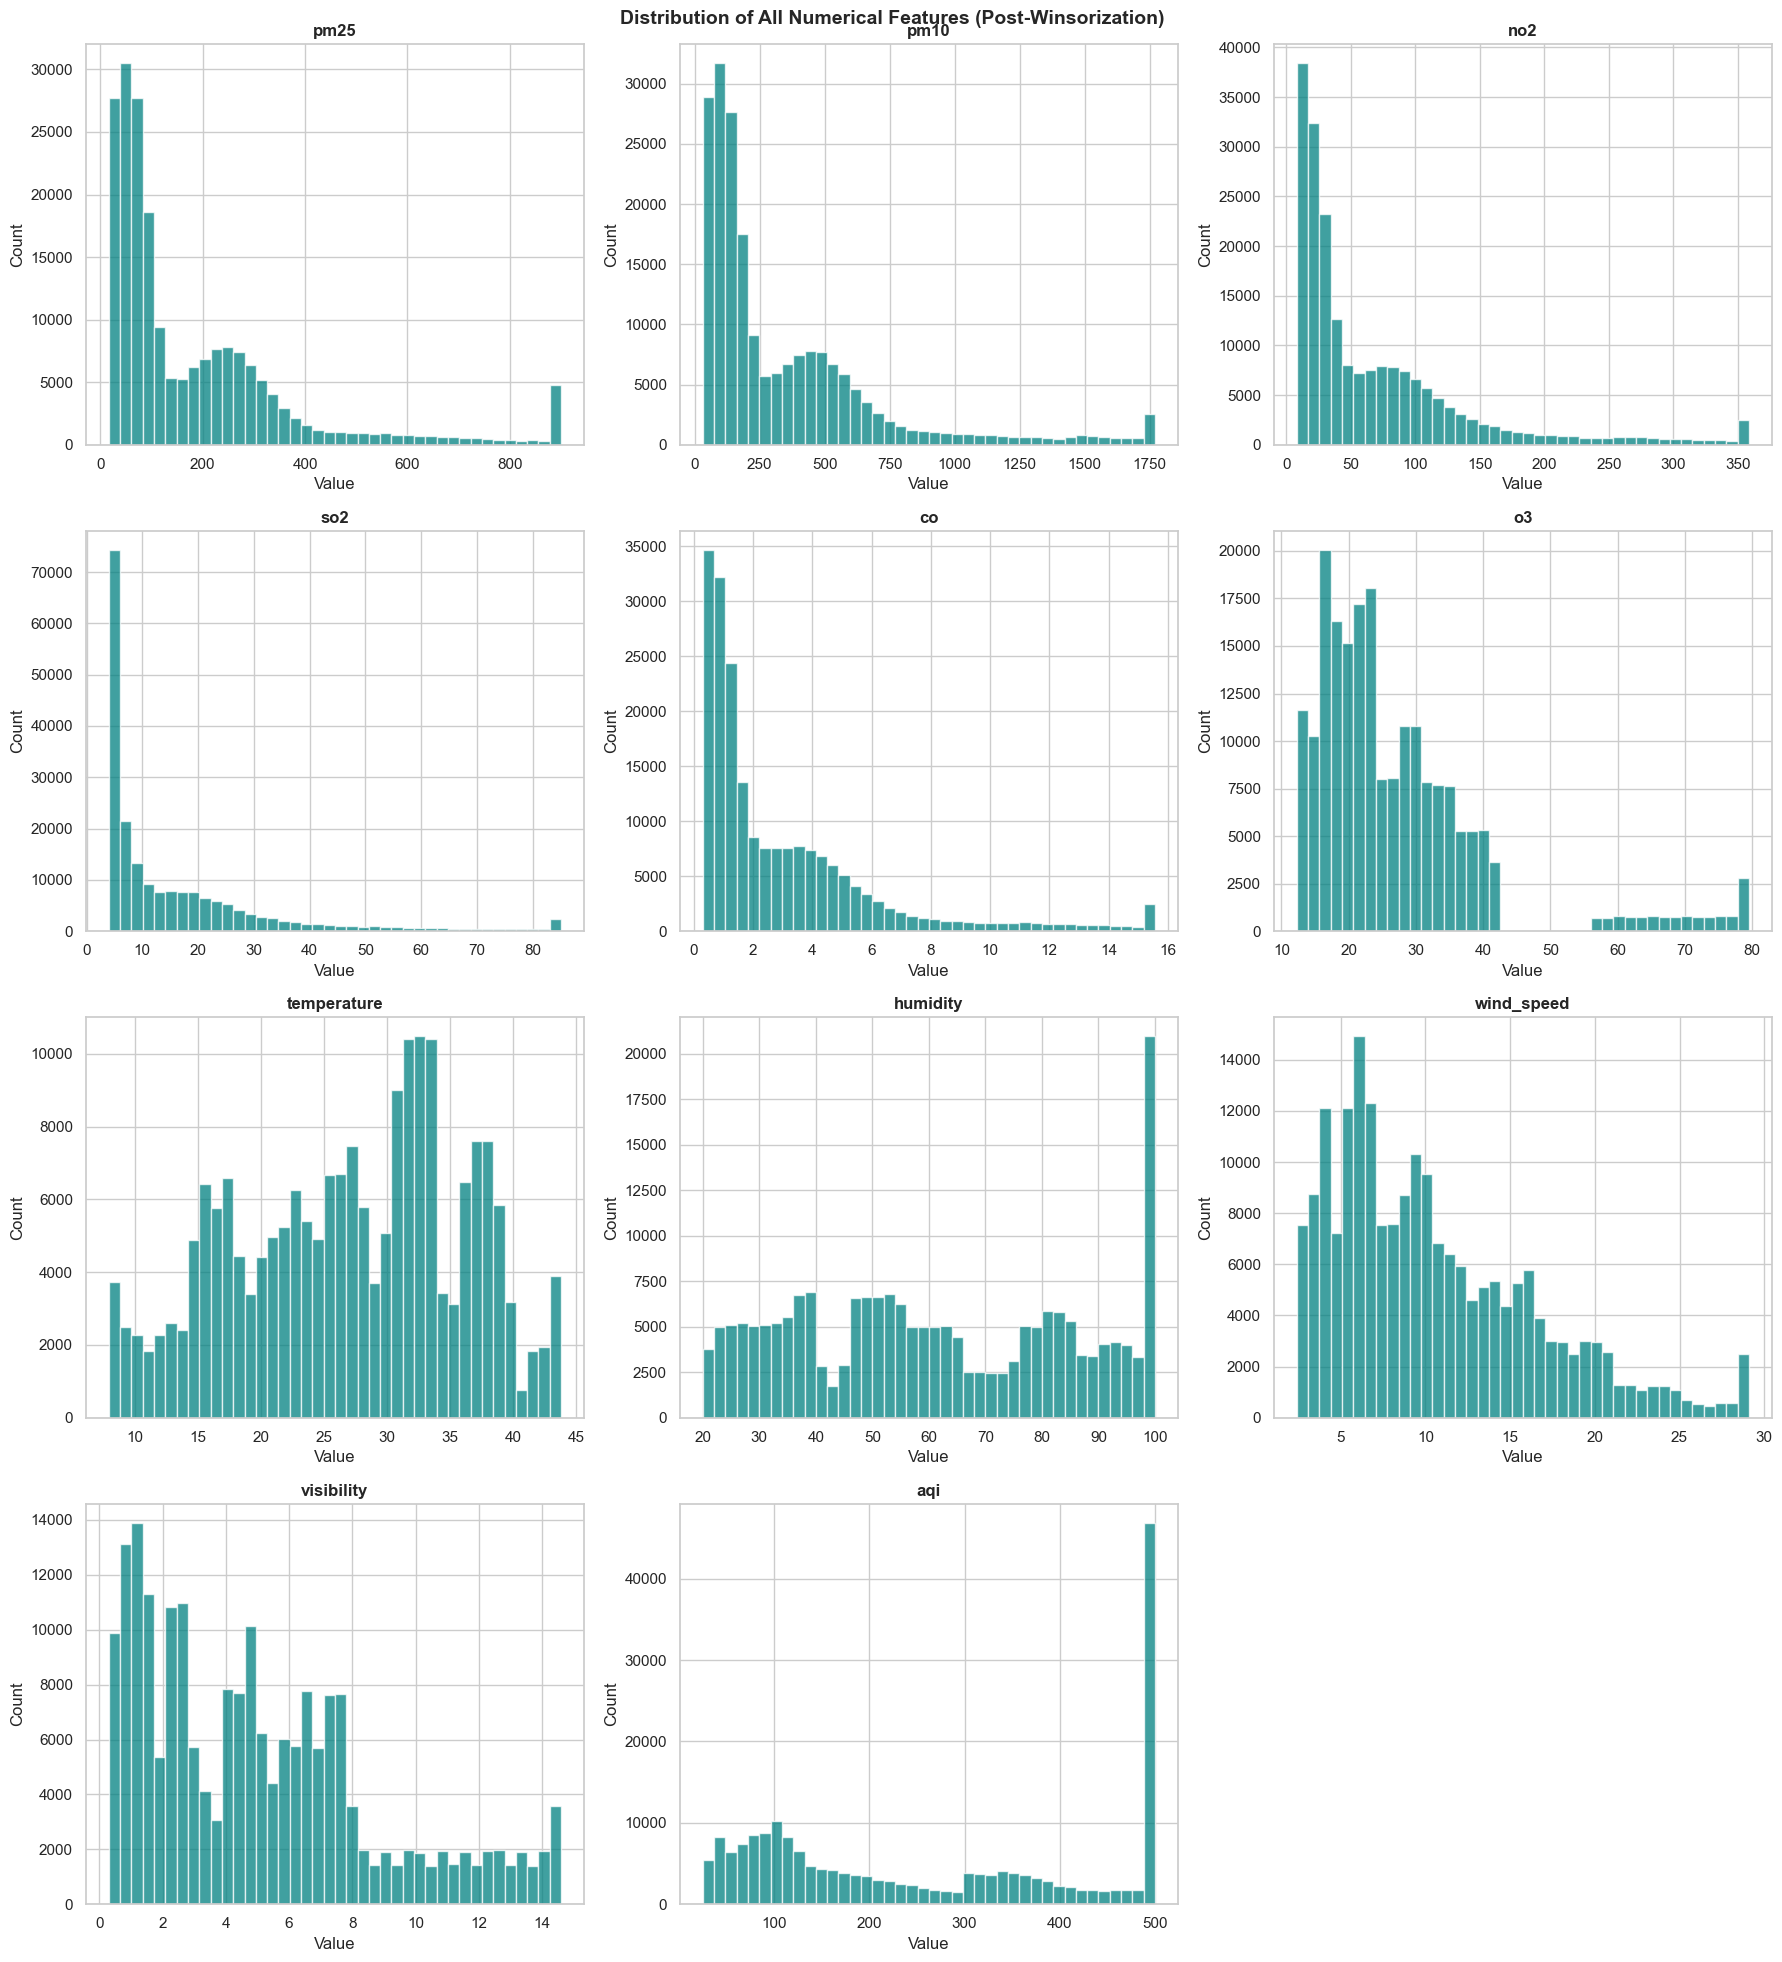

In [10]:
num_features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
                'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df_clean[col], bins=40, color='teal', edgecolor='white', alpha=0.75)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide extra subplot
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numerical Features (Post-Winsorization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution of All Numerical Features

# Categorical Feature Analysis

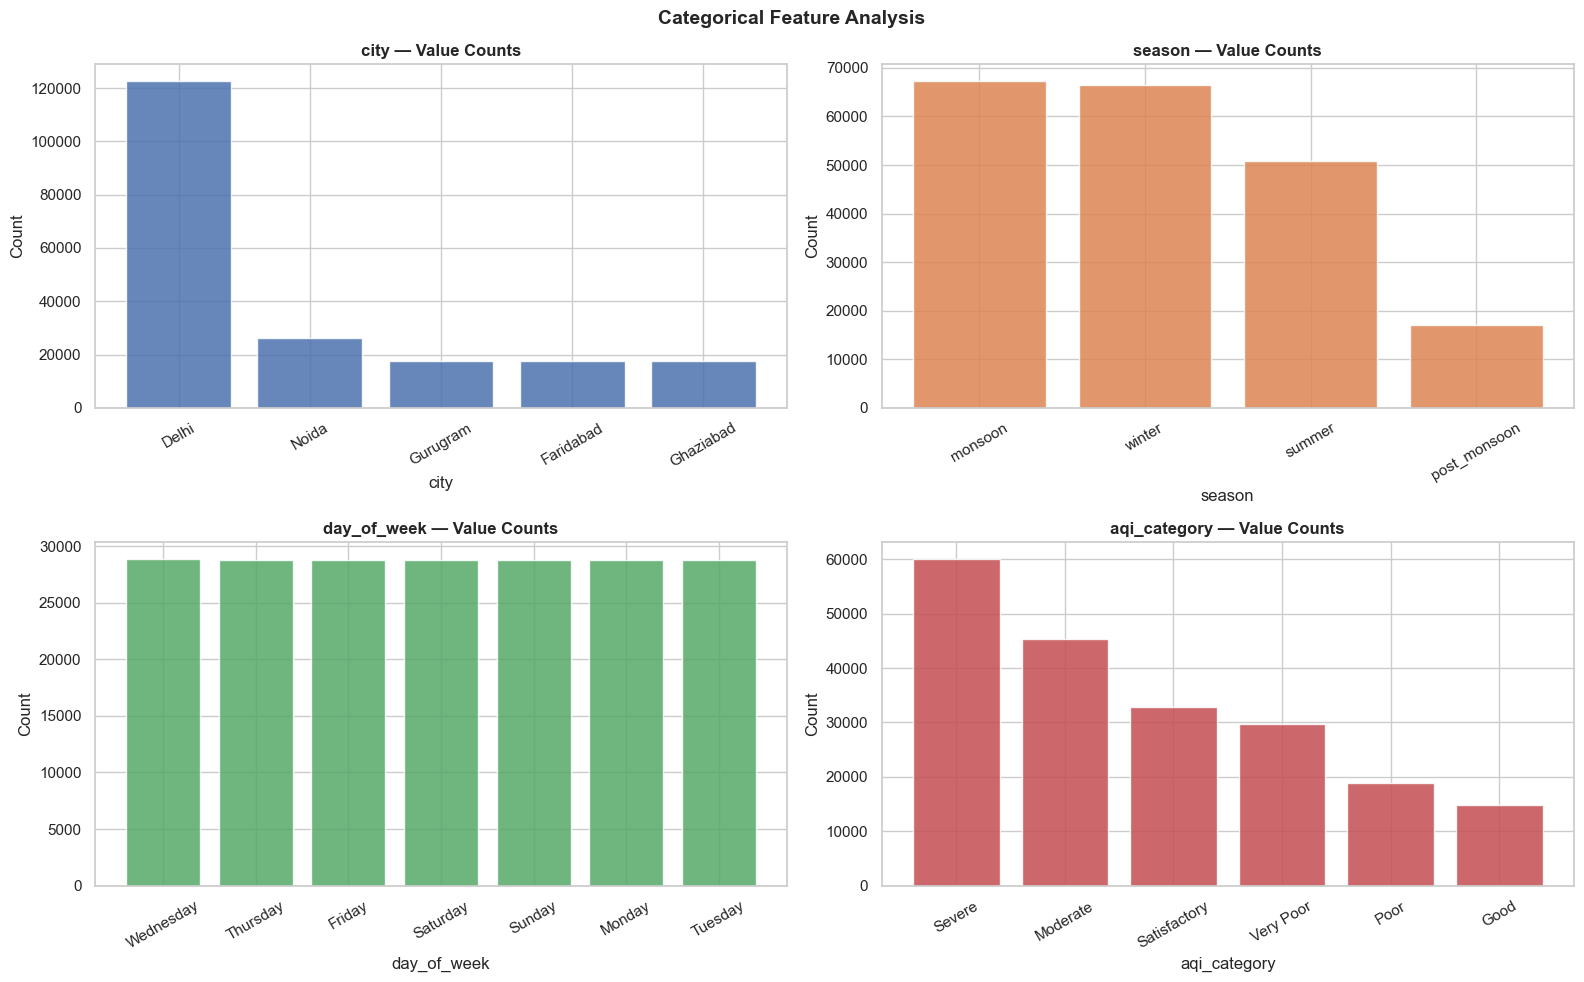

In [11]:
cat_cols = ['city', 'season', 'day_of_week', 'aqi_category']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, col in enumerate(cat_cols):
    vc = df_clean[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} — Value Counts', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PM2.5 by City and Season

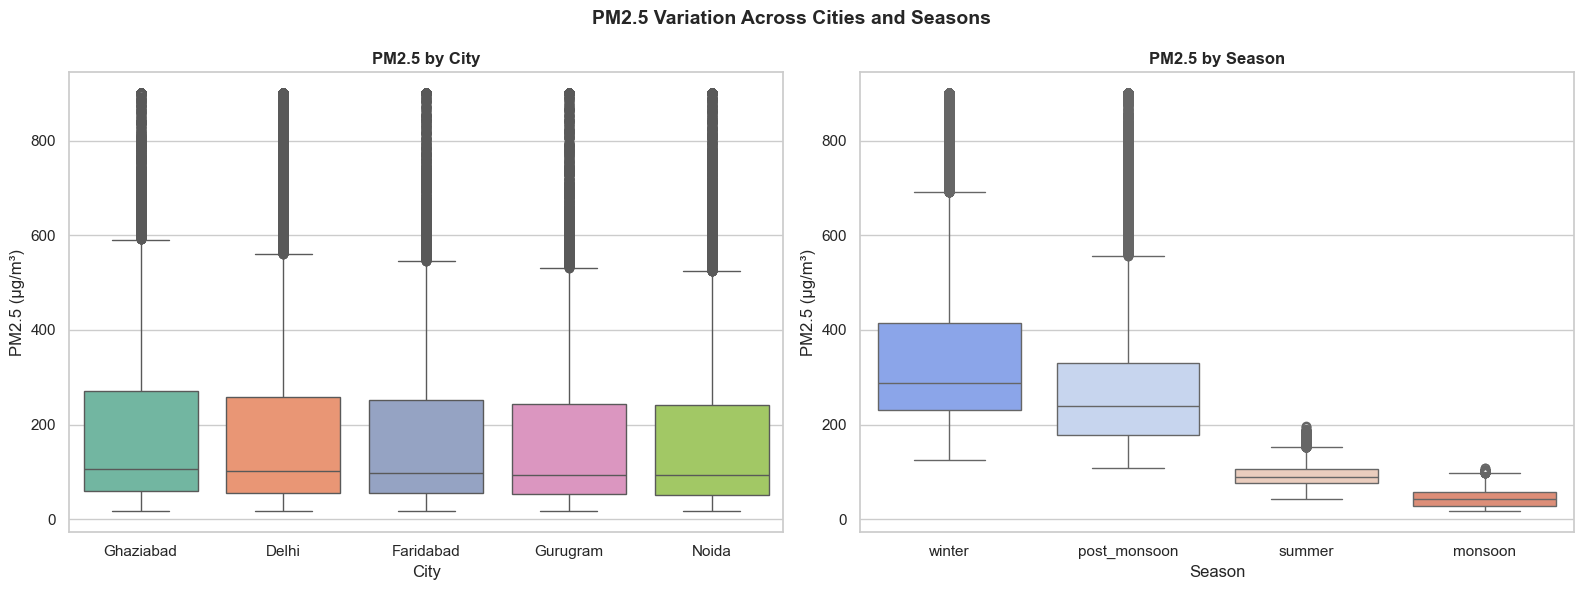

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PM2.5 by City
city_order = df_clean.groupby('city')['pm25'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='city', y='pm25', order=city_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('PM2.5 by City', fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('PM2.5 (µg/m³)')

# PM2.5 by Season
season_order = ['winter', 'post_monsoon', 'summer', 'monsoon']
sns.boxplot(data=df_clean, x='season', y='pm25', order=season_order,
            palette='coolwarm', ax=axes[1])
axes[1].set_title('PM2.5 by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.suptitle('PM2.5 Variation Across Cities and Seasons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Heatmap

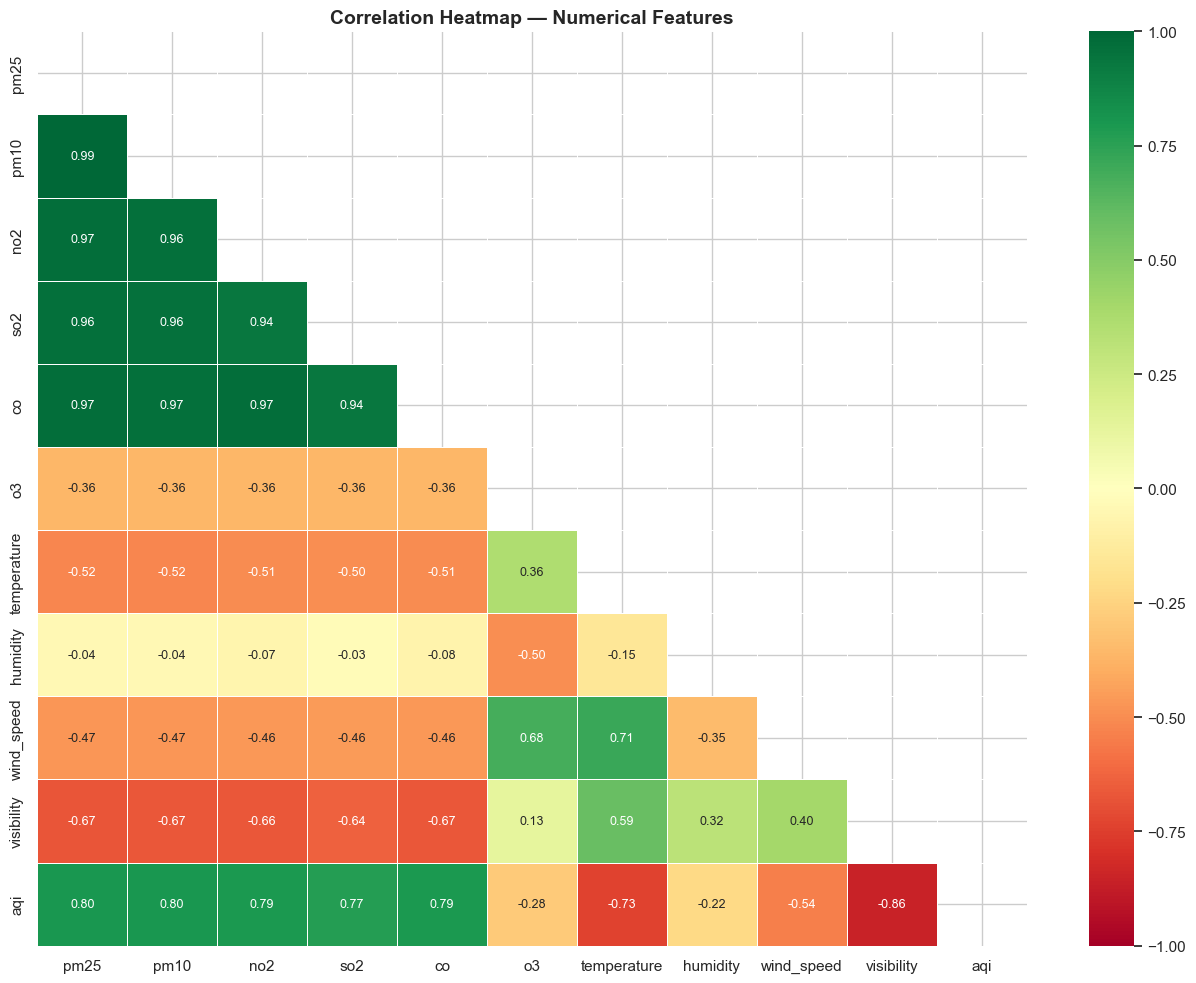

Top Correlations with PM2.5:
pm25           1.000000
pm10           0.993075
co             0.971492
no2            0.970611
so2            0.964400
aqi            0.800808
humidity      -0.042300
o3            -0.363822
wind_speed    -0.471878
temperature   -0.518284
visibility    -0.672748
Name: pm25, dtype: float64


In [13]:
corr_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
             'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with PM2.5
print('Top Correlations with PM2.5:')
print(corr_matrix['pm25'].sort_values(ascending=False))

# Time Trends: PM2.5 Over the Years

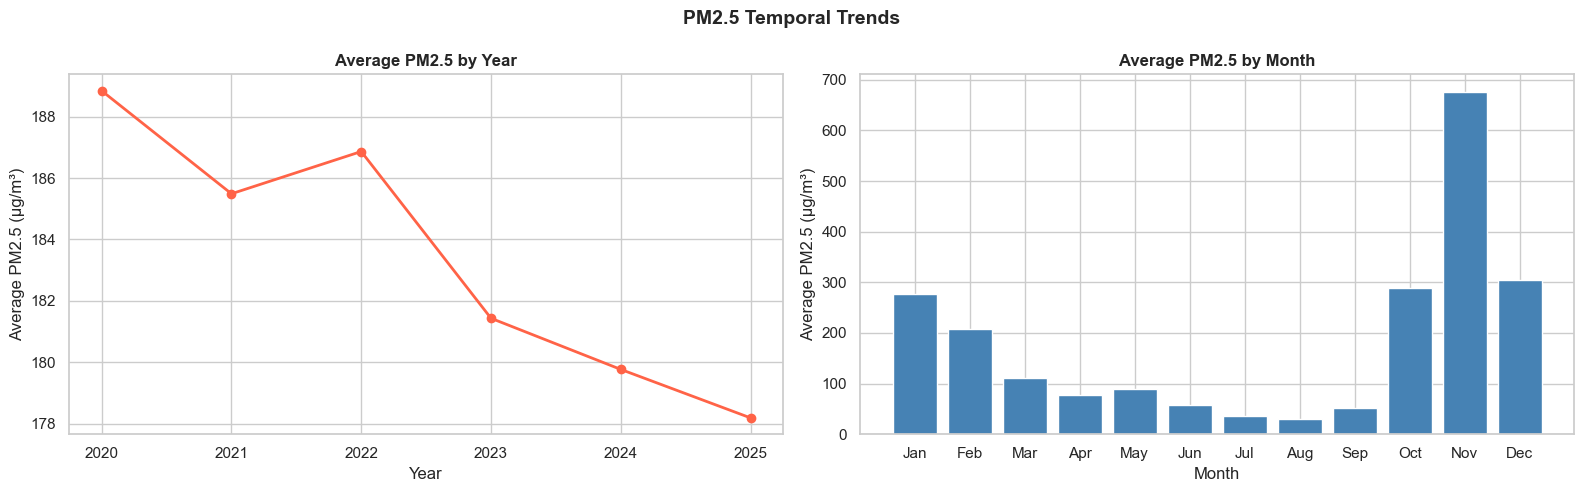

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Yearly trend
yearly = df_clean.groupby('year')['pm25'].mean()
axes[0].plot(yearly.index, yearly.values, marker='o', color='tomato', linewidth=2)
axes[0].set_title('Average PM2.5 by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average PM2.5 (µg/m³)')

# Monthly trend
monthly = df_clean.groupby('month')['pm25'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Average PM2.5 by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average PM2.5 (µg/m³)')

plt.suptitle('PM2.5 Temporal Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Categorical Encoding

In [15]:
df_encoded = df_clean.copy()

# 1. ORDINAL ENCODING — aqi_category (has natural order: Good < Satisfactory < ... < Severe)
aqi_order = [['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']]
oe = OrdinalEncoder(categories=aqi_order)
df_encoded['aqi_category_encoded'] = oe.fit_transform(df_encoded[['aqi_category']]).astype(int)
print('Ordinal Encoding — aqi_category:')
print(df_encoded[['aqi_category', 'aqi_category_encoded']].drop_duplicates().sort_values('aqi_category_encoded'))

# 2. LABEL ENCODING — season (used for tree models)
le = LabelEncoder()
df_encoded['season_encoded'] = le.fit_transform(df_encoded['season'])
print('\nLabel Encoding — season:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

# 3. ONE-HOT ENCODING — city, day_of_week (no inherent order)
df_encoded = pd.get_dummies(df_encoded, columns=['city', 'day_of_week'], drop_first=True)
print('\nOne-Hot Encoding applied for city and day_of_week.')

# Drop original string columns no longer needed
df_encoded.drop(columns=['datetime', 'date', 'station', 'season', 'aqi_category'], inplace=True)

print(f'\n✅ Encoded dataset shape: {df_encoded.shape}')
df_encoded.head()

Ordinal Encoding — aqi_category:
       aqi_category  aqi_category_encoded
14049          Good                     0
8481   Satisfactory                     1
5541       Moderate                     2
5521           Poor                     3
5         Very Poor                     4
0            Severe                     5

Label Encoding — season:
{'monsoon': np.int64(0), 'post_monsoon': np.int64(1), 'summer': np.int64(2), 'winter': np.int64(3)}

One-Hot Encoding applied for city and day_of_week.

✅ Encoded dataset shape: (201664, 30)


,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,...,city_Faridabad,city_Ghaziabad,city_Gurugram,city_Noida,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2020,1,1,6,0,28.6469,77.3164,371.8,739.4,119.6,...,False,False,False,False,False,False,False,False,False,True
1,2020,1,1,12,0,28.6469,77.3164,301.1,588.8,117.9,...,False,False,False,False,False,False,False,False,False,True
2,2020,1,1,18,0,28.6469,77.3164,334.0,602.6,150.1,...,False,False,False,False,False,False,False,False,False,True
3,2020,1,1,23,0,28.6469,77.3164,403.8,841.8,142.0,...,False,False,False,False,False,False,False,False,False,True
4,2020,1,1,6,0,28.7299,77.1718,433.2,784.7,138.4,...,False,False,False,False,False,False,False,False,False,True


# Feature Standardization (Z-score)

In [16]:
# Separate features (X) and target (y)
target = 'pm25'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Identify columns to scale (numerical, non-binary)
binary_cols = [c for c in X.columns if X[c].nunique() == 2]
scale_cols  = [c for c in X.select_dtypes(include=[np.number]).columns if c not in binary_cols]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'Scaled {len(scale_cols)} columns: {scale_cols[:6]} ...')
print(f'Left {len(binary_cols)} binary columns unscaled.')

# Verify: mean ≈ 0, std ≈ 1 after scaling
stats_after = X_scaled[scale_cols].agg(['mean', 'std']).round(3)
print('\nPost-scaling statistics (first 5 cols):')
print(stats_after[scale_cols[:5]])
print('\n✅ Standardization complete!')

Scaled 18 columns: ['year', 'month', 'day', 'hour', 'latitude', 'longitude'] ...
Left 11 binary columns unscaled.

Post-scaling statistics (first 5 cols):
      year  month  day  hour  latitude
mean   0.0    0.0  0.0   0.0       0.0
std    1.0    1.0  1.0   1.0       1.0

✅ Standardization complete!


# Class Imbalance Analysis

=== CLASS DISTRIBUTION ===
Severe         :  60,102 ( 29.8%) ██████████████
Moderate       :  45,397 ( 22.5%) ███████████
Satisfactory   :  32,860 ( 16.3%) ████████
Very Poor      :  29,674 ( 14.7%) ███████
Poor           :  18,843 (  9.3%) ████
Good           :  14,788 (  7.3%) ███


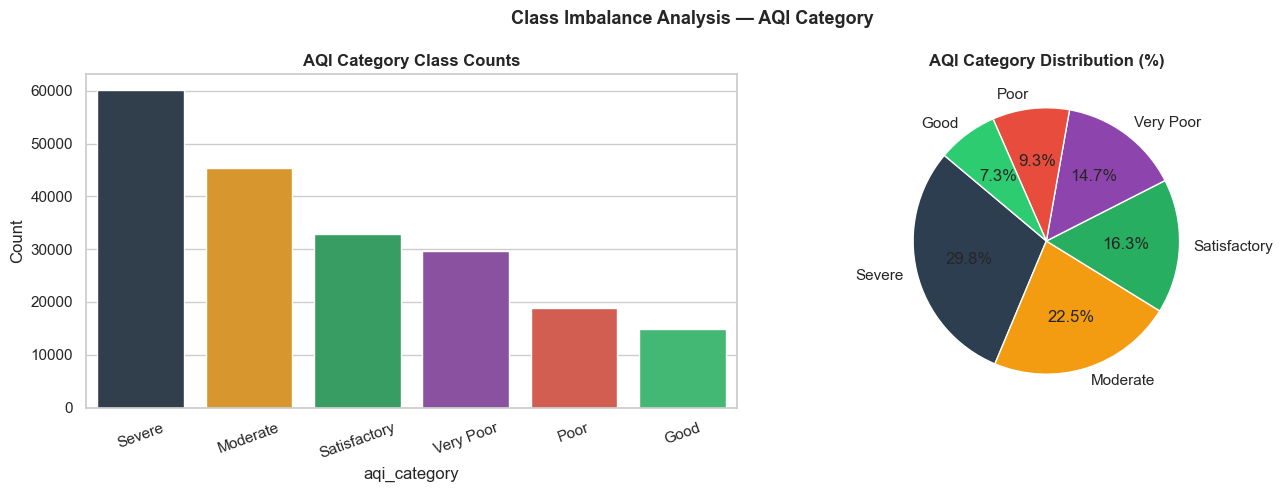

In [17]:
# For classification tasks, use aqi_category as the class label
# Re-encode from df_clean for clear visualization
class_counts = df_clean['aqi_category'].value_counts()
class_pct    = (class_counts / class_counts.sum() * 100).round(2)

print('=== CLASS DISTRIBUTION ===')
for cat, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    bar = '█' * int(pct / 2)
    print(f'{cat:15s}: {cnt:7,d} ({pct:5.1f}%) {bar}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Good':'#2ecc71', 'Satisfactory':'#27ae60', 'Moderate':'#f39c12',
           'Poor':'#e74c3c', 'Very Poor':'#8e44ad', 'Severe':'#2c3e50'}

sns.barplot(x=class_counts.index, y=class_counts.values,
            palette=palette, ax=axes[0])
axes[0].set_title('AQI Category Class Counts', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=[palette[k] for k in class_counts.index],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('AQI Category Distribution (%)', fontweight='bold')

plt.suptitle('Class Imbalance Analysis — AQI Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Managing Class Imbalance (SMOTE)

Class distribution BEFORE SMOTE:
aqi_category_encoded
0    14788
1    32860
2    45397
3    18843
4    29674
5    60102
Name: count, dtype: int64

Class distribution AFTER SMOTE:
aqi_category_encoded
0    60102
1    60102
2    60102
3    60102
4    60102
5    60102
Name: count, dtype: int64


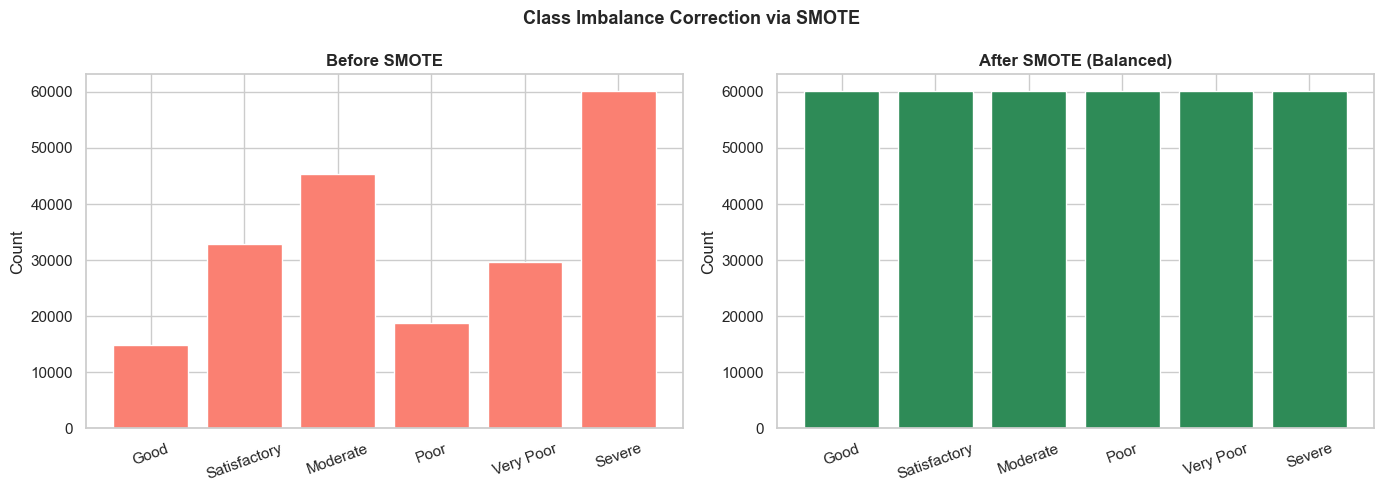


✅ Resampled dataset: 360612 rows (was 201664)


In [18]:
# Use aqi_category_encoded as the class label for SMOTE
X_cls = X_scaled.copy()
y_cls = df_encoded['aqi_category_encoded']

print('Class distribution BEFORE SMOTE:')
print(y_cls.value_counts().sort_index())

smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_cls, y_cls)

print('\nClass distribution AFTER SMOTE:')
after = pd.Series(y_resampled).value_counts().sort_index()
print(after)

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = y_cls.value_counts().sort_index()
label_map = {0:'Good', 1:'Satisfactory', 2:'Moderate', 3:'Poor', 4:'Very Poor', 5:'Severe'}

axes[0].bar([label_map[i] for i in before_counts.index], before_counts.values,
            color='salmon', edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar([label_map[i] for i in after.index], after.values,
            color='seagreen', edgecolor='white')
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Class Imbalance Correction via SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Resampled dataset: {X_resampled.shape[0]} rows (was {X_cls.shape[0]})')

# Final Preprocessed Dataset Summary

In [19]:
print('=' * 55)
print('       PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Original Shape         : {df.shape}')
print(f'Post-Winsorization     : {df_clean.shape}')
print(f'Post-Encoding Shape    : {df_encoded.shape}')
print(f'X (features) Shape     : {X_scaled.shape}')
print(f'y (target) Shape       : {y.shape}')
print(f'X_resampled (SMOTE)    : {X_resampled.shape}')
print('=' * 55)
print('Steps Completed:')
steps = [
    '✅ Data loading & overview',
    '✅ Missing value analysis & expert imputation strategy',
    '✅ Outlier detection (IQR method) & Winsorization',
    '✅ Visualizations: histograms, boxplots, KDE, heatmap, pairplot, time trends',
    '✅ Categorical encoding: Ordinal, Label, One-Hot',
    '✅ Feature standardization (StandardScaler)',
    '✅ Class imbalance analysis & correction (SMOTE)',
]
for s in steps:
    print(f'  {s}')

print('\nDataset is ready for modelling!')

       PREPROCESSING SUMMARY
Original Shape         : (201664, 25)
Post-Winsorization     : (201664, 25)
Post-Encoding Shape    : (201664, 30)
X (features) Shape     : (201664, 29)
y (target) Shape       : (201664,)
X_resampled (SMOTE)    : (360612, 29)
Steps Completed:
  ✅ Data loading & overview
  ✅ Missing value analysis & expert imputation strategy
  ✅ Outlier detection (IQR method) & Winsorization
  ✅ Visualizations: histograms, boxplots, KDE, heatmap, pairplot, time trends
  ✅ Categorical encoding: Ordinal, Label, One-Hot
  ✅ Feature standardization (StandardScaler)
  ✅ Class imbalance analysis & correction (SMOTE)

Dataset is ready for modelling!


#**Import Libraries**

In [20]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

#**loding the dataa**

In [21]:
df_encoded.to_csv("cleaned_data.csv", index=False)
final_df = pd.read_csv("cleaned_data.csv")

##**features and target**

In [22]:
X = final_df.drop(['pm25', 'datetime', 'date', 'aqi', 'aqi_category'], axis=1, errors='ignore')
y = final_df['pm25']

#**# Split data into training and testing sets**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#**Initialize the base XGBoost model**

In [24]:
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)


#**Set up hyperparameter grid for tuning**

In [25]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

#**Perform GridSearchCV for hyperparameter tuning**

In [26]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


#**Best parameters & best model**

In [27]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


#**Evaluate Model on Test Data**

In [28]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


Model Performance:
MAE: 6.556
MSE: 148.086
RMSE: 12.169
R² Score: 0.996


#**Feature Importance**

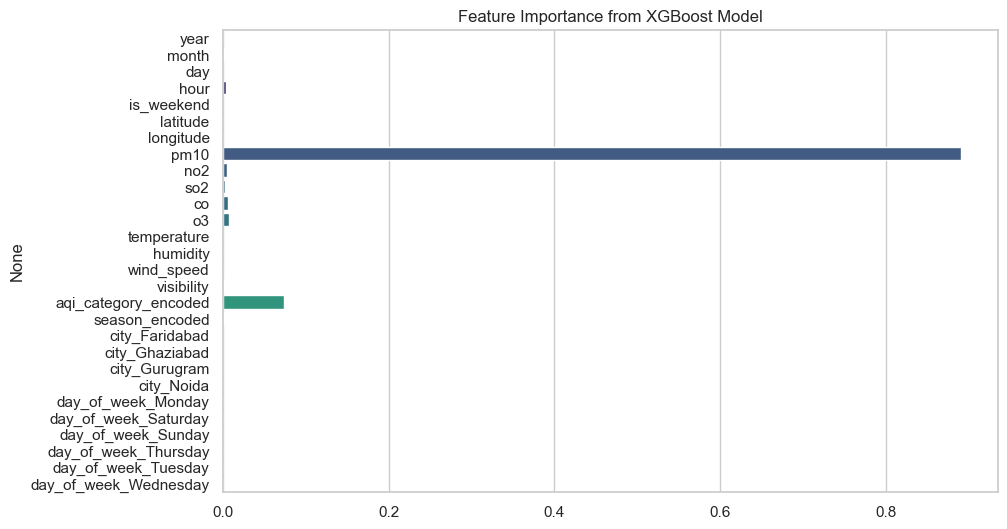

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(
    x=best_model.feature_importances_,
    y=X.columns,
    palette="viridis"
)
plt.title("Feature Importance from XGBoost Model")
plt.show()

In [30]:

from sklearn.model_selection import ParameterGrid

results = []

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for params in ParameterGrid(param_grid):
    
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **params
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        **params,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save to Excel
results_df.to_excel("model_results.xlsx", index=False)

print("✅ Done! Excel file created")

✅ Done! Excel file created


In [31]:
import numpy as np
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# -------------------------------------------
# Hyperparameter values (~32 models example)
# -------------------------------------------
n_estimators = [100, 200]
learning_rate = [0.01, 0.05]
max_depth = [3, 5]
subsample = [0.7, 0.8]
colsample_bytree = [0.7, 0.8]

param_combinations = list(product(
    n_estimators,
    learning_rate,
    max_depth,
    subsample,
    colsample_bytree
))

# -------------------------------------------
# Loop and print results
# -------------------------------------------
for i, (n_est, lr, md, ss, cs) in enumerate(param_combinations):

    model = XGBRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=md,
        subsample=ss,
        colsample_bytree=cs,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n🔹 Model {i+1}")
    print(f"Params: n_estimators={n_est}, lr={lr}, max_depth={md}, subsample={ss}, colsample={cs}")
    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")


🔹 Model 1
Params: n_estimators=100, lr=0.01, max_depth=3, subsample=0.7, colsample=0.7
MAE: 53.656 | MSE: 5661.229 | RMSE: 75.241 | R2: 0.848

🔹 Model 2
Params: n_estimators=100, lr=0.01, max_depth=3, subsample=0.7, colsample=0.8
MAE: 53.581 | MSE: 5601.025 | RMSE: 74.840 | R2: 0.850

🔹 Model 3
Params: n_estimators=100, lr=0.01, max_depth=3, subsample=0.8, colsample=0.7
MAE: 53.634 | MSE: 5663.382 | RMSE: 75.255 | R2: 0.848

🔹 Model 4
Params: n_estimators=100, lr=0.01, max_depth=3, subsample=0.8, colsample=0.8
MAE: 53.594 | MSE: 5599.095 | RMSE: 74.827 | R2: 0.850

🔹 Model 5
Params: n_estimators=100, lr=0.01, max_depth=5, subsample=0.7, colsample=0.7
MAE: 52.477 | MSE: 5358.026 | RMSE: 73.199 | R2: 0.856

🔹 Model 6
Params: n_estimators=100, lr=0.01, max_depth=5, subsample=0.7, colsample=0.8
MAE: 52.471 | MSE: 5323.661 | RMSE: 72.963 | R2: 0.857

🔹 Model 7
Params: n_estimators=100, lr=0.01, max_depth=5, subsample=0.8, colsample=0.7
MAE: 52.472 | MSE: 5357.925 | RMSE: 73.198 | R2: 0.856

#**finding best modles**

In [33]:
best_r2 = -999
best_info = None

for i, (n_est, lr, md, ss, cs) in enumerate(param_combinations):

    model = XGBRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=md,
        subsample=ss,
        colsample_bytree=cs,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    if r2 > best_r2:
        best_r2 = r2
        best_info = (n_est, lr, md, ss, cs)

print("\n Best Model:")
print(f"R2: {best_r2:.3f}")
print(f"Params: {best_info}")


 Best Model:
R2: 0.995
Params: (200, 0.05, 5, 0.8, 0.7)
